In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
dic_vert_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/dic_vert_doppio_AMEDA.pkl')
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl')


Eddy dataset


Things to compare
1. max r
2. max tangential velocity
3. vorticity
4. area

In [4]:
df_phys_geom = df_ameda[['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'xc', 'yc', 'w',
       'ke', 'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'area', 'deta']]

df_phys_geom = df_phys_geom.rename(columns={
                    'lon': 'plon',
                    'lat': 'plat',
                    'xc': 'pxc',
                    'yc': 'pyc',
                    'w': 'pw',
                })

cols = ['xc', 'yc',
    'w', 'Omega0', 'Omega', 'Q',
    'Rc', 'psi0', 'R'
]

out = []

for row in df_phys_geom.itertuples(index=False):

    # try:
    df = dic_vert_ameda[f'Eddy{row.Eddy}'][f'Day{row.Day}']
    if len(df):
        data_top = df.iloc[0][cols]
    else:
        data_top = pd.Series(np.nan, index=cols)

    out.append(data_top)

df_top = pd.DataFrame(out).reset_index(drop=True)

df_phys_geom = pd.concat(
    [df_phys_geom.reset_index(drop=True), df_top],
    axis=1
)

df_phys_geom = df_phys_geom.rename(columns={
                    'xc': 'gxc',
                    'yc': 'gyc',
                    'w': 'gw',
                })

points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
values = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])

df_phys_geom[['glon', 'glat']] = griddata(
    points,
    values,
    (df_phys_geom['gxc'].to_numpy(), df_phys_geom['gyc'].to_numpy()),
    method='linear'
)


In [5]:
df_phys_geom


,Eddy,Day,Cyc,plon,plat,pxc,pyc,pw,ke,velmax,...,gyc,gw,Omega0,Omega,Q,Rc,psi0,R,glon,glat
0,1,1462,AE,159.538447,-33.372496,895.838095,919.548973,0.000010,292.285615,0.544839,...,914.018437,0.000027,0.000013,0.000016,"[[1.1484970435920865, -0.16686898267851438], [...",76.216389,-4.709353e+01,50.205273,159.534173,-33.423243
1,1,1463,AE,159.686966,-33.160751,903.002279,946.853133,0.000019,11.362536,0.345677,...,945.300803,0.000027,0.000013,0.000013,"[[1.1014165403553098, 0.08390953388558413], [0...",84.056157,-4.612005e+01,56.641660,159.676398,-33.172138
2,1,1464,AE,159.649836,-33.118402,898.424872,950.150915,0.000019,12.635252,0.358493,...,951.755290,0.000028,0.000014,0.000014,"[[1.1474072104379092, 0.09543483784981353], [0...",70.983917,-3.550560e+01,46.977663,159.661607,-33.106891
3,1,1465,AE,159.686966,-33.118402,901.765461,951.353349,0.000019,29.826388,0.435328,...,953.702712,0.000032,0.000016,0.000015,"[[1.0369072488316746, 0.24215822157703532], [0...",70.511257,-3.841341e+01,48.730042,159.670894,-33.091393
4,1,1466,AE,159.575577,-32.949006,886.770848,965.738198,0.000020,28.475320,0.442656,...,960.347517,0.000035,0.000017,0.000016,"[[1.022111462750352, 0.14391176963720498], [0....",65.650567,-3.539335e+01,43.505985,159.540239,-32.988978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,327.112431,1244.142958,-0.000014,0.302780,0.127185,...,1240.337375,-0.000016,-0.000007,-0.000009,"[[0.7772149834805244, 0.4056803792731006], [0....",115.522788,6.287183e+01,62.433731,154.865076,-28.867420
104566,3519,10647,CE,154.860106,-29.052897,331.141370,1220.843200,-0.000011,14.401765,0.221221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104567,3519,10648,CE,154.897235,-29.222293,340.502393,1204.416117,-0.000011,16.134916,0.250150,...,1242.855587,-0.000024,-0.000005,-0.000003,"[[2.379027060784385, 2.3814168849882056], [2.3...",24951.145880,1.050213e+06,33.659059,154.599798,-28.758647
104568,3519,10649,CE,154.377420,-28.417662,264.105244,1270.945276,-0.000010,3.093473,0.189983,...,1262.259287,-0.000015,-0.000007,-0.000006,"[[1.0691646288134213, 0.4616523150827176], [0....",60.067356,1.071680e+01,23.061186,154.473252,-28.531810


In [6]:
def is_valid_Q(Q):
    return isinstance(Q, np.ndarray) and Q.shape == (2, 2) and np.isfinite(Q).all()

ARs = np.full(len(df_phys_geom), np.nan)

valid = df_phys_geom['Q'].apply(is_valid_Q)

if valid.any():
    Q_stack = np.stack(df_phys_geom.loc[valid, 'Q'].values)
    ARs[valid.values] = compute_AR_from_Q(Q_stack)

df_phys_geom['AR'] = ARs


In [7]:
# Check AR
# if poor only keep Eddy, Day, Cyc, xc, yc, R
# replace the rest NaN

df_phys_geom_QC = df_phys_geom.copy()

AR_mask = df_phys_geom_QC['AR'] > 5
cols_to_nan = [
    'gw', 'Omega',
    'Q', 'Rc', 'psi0', 'AR'
]
df_phys_geom_QC.loc[AR_mask, cols_to_nan] = np.nan

# Check Omega, Rc, psi0 i.e. poor outer-core fits
poor_outer_fits = (
    (df_phys_geom_QC['Rc'] > 300)
    | (df_phys_geom_QC['Rc'] > 1.75*df_phys_geom_QC['R'])
    | (df_phys_geom_QC['Omega'].abs() > 5e-5)
    # | (df_phys_geom_QC['psi0'].abs() > 300)
)
# replace Omega with Omega0
df_phys_geom_QC.loc[poor_outer_fits, 'Omega'] = (
    df_phys_geom_QC.loc[poor_outer_fits, 'Omega0']
)

# remove poor outer-core parameters
df_phys_geom_QC.loc[poor_outer_fits, ['Rc', 'psi0']] = np.nan

df_phys_geom_QC = df_phys_geom_QC.drop(columns='Omega0')
df_phys_geom_QC


,Eddy,Day,Cyc,plon,plat,pxc,pyc,pw,ke,velmax,...,gyc,gw,Omega,Q,Rc,psi0,R,glon,glat,AR
0,1,1462,AE,159.538447,-33.372496,895.838095,919.548973,0.000010,292.285615,0.544839,...,914.018437,0.000027,0.000016,"[[1.1484970435920865, -0.16686898267851438], [...",76.216389,-47.093534,50.205273,159.534173,-33.423243,1.231286
1,1,1463,AE,159.686966,-33.160751,903.002279,946.853133,0.000019,11.362536,0.345677,...,945.300803,0.000027,0.000013,"[[1.1014165403553098, 0.08390953388558413], [0...",84.056157,-46.120052,56.641660,159.676398,-33.172138,1.133534
2,1,1464,AE,159.649836,-33.118402,898.424872,950.150915,0.000019,12.635252,0.358493,...,951.755290,0.000028,0.000014,"[[1.1474072104379092, 0.09543483784981353], [0...",70.983917,-35.505599,46.977663,159.661607,-33.106891,1.177924
3,1,1465,AE,159.686966,-33.118402,901.765461,951.353349,0.000019,29.826388,0.435328,...,953.702712,0.000032,0.000015,"[[1.0369072488316746, 0.24215822157703532], [0...",70.511257,-38.413409,48.730042,159.670894,-33.091393,1.271223
4,1,1466,AE,159.575577,-32.949006,886.770848,965.738198,0.000020,28.475320,0.442656,...,960.347517,0.000035,0.000016,"[[1.022111462750352, 0.14391176963720498], [0....",65.650567,-35.393353,43.505985,159.540239,-32.988978,1.154760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,327.112431,1244.142958,-0.000014,0.302780,0.127185,...,1240.337375,-0.000016,-0.000007,"[[0.7772149834805244, 0.4056803792731006], [0....",NaN,NaN,62.433731,154.865076,-28.867420,1.680579
104566,3519,10647,CE,154.860106,-29.052897,331.141370,1220.843200,-0.000011,14.401765,0.221221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104567,3519,10648,CE,154.897235,-29.222293,340.502393,1204.416117,-0.000011,16.134916,0.250150,...,1242.855587,-0.000024,-0.000005,"[[2.379027060784385, 2.3814168849882056], [2.3...",NaN,NaN,33.659059,154.599798,-28.758647,4.982473
104568,3519,10649,CE,154.377420,-28.417662,264.105244,1270.945276,-0.000010,3.093473,0.189983,...,1262.259287,-0.000015,-0.000007,"[[1.0691646288134213, 0.4616523150827176], [0....",NaN,NaN,23.061186,154.473252,-28.531810,1.564717


In [8]:
def compare_phys_geom(
    df,
    xcol,
    ycol,
    cyc_col='Cyc',
    figsize=(5, 5),
    s=1,
    alpha=0.5,
    fit=True,
    one_to_one=True,
    ax=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    colors = {'AE': 'r', 'CE': 'c'}

    for cyc in ['AE', 'CE']:

        dfm = df[df[cyc_col] == cyc]

        x = dfm[xcol].values
        y = dfm[ycol].values

        mask = np.isfinite(x) & np.isfinite(y)

        x = x[mask]
        y = y[mask]

        ax.scatter(
            x,
            y,
            marker='.',
            s=s,
            alpha=alpha,
            color=colors[cyc],
            label=cyc
        )

        if fit and len(x) > 1:

            p = np.polyfit(x, y, 1)

            xf = np.linspace(x.min(), x.max(), 100)

            ax.plot(
                xf,
                np.polyval(p, xf),
                color='m' if cyc=='AE' else 'b', #colors[cyc],
                lw=2,
                label=f"{cyc}: y={p[0]:.2f}x{'+' if p[1] > 0 else '-'}{abs(p[1]):.2f}"
            )

    lims = [
        np.nanmin([ax.get_xlim()[0], ax.get_ylim()[0]]),
        np.nanmax([ax.get_xlim()[1], ax.get_ylim()[1]])
    ]

    if one_to_one:
        ax.plot(lims, lims, 'k--', label='y=x')

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_aspect('equal')

    ax.legend(frameon=False)
    
    return
    

In [9]:
df_phys_geom_QC['Omega']

0         0.000016
1         0.000013
2         0.000014
3         0.000015
4         0.000016
            ...   
104565   -0.000007
104566         NaN
104567   -0.000005
104568   -0.000007
104569   -0.000007
Name: Omega, Length: 104570, dtype: float64

In [10]:
df_phys_geom_QC.Omega,df_phys_geom_QC.Rc,np.exp(-.5),(np.sqrt(2))


(0         0.000016
 1         0.000013
 2         0.000014
 3         0.000015
 4         0.000016
             ...   
 104565   -0.000007
 104566         NaN
 104567   -0.000005
 104568   -0.000007
 104569   -0.000007
 Name: Omega, Length: 104570, dtype: float64,
 0         76.216389
 1         84.056157
 2         70.983917
 3         70.511257
 4         65.650567
             ...    
 104565          NaN
 104566          NaN
 104567          NaN
 104568          NaN
 104569          NaN
 Name: Rc, Length: 104570, dtype: float64,
 np.float64(0.6065306597126334),
 np.float64(1.4142135623730951))

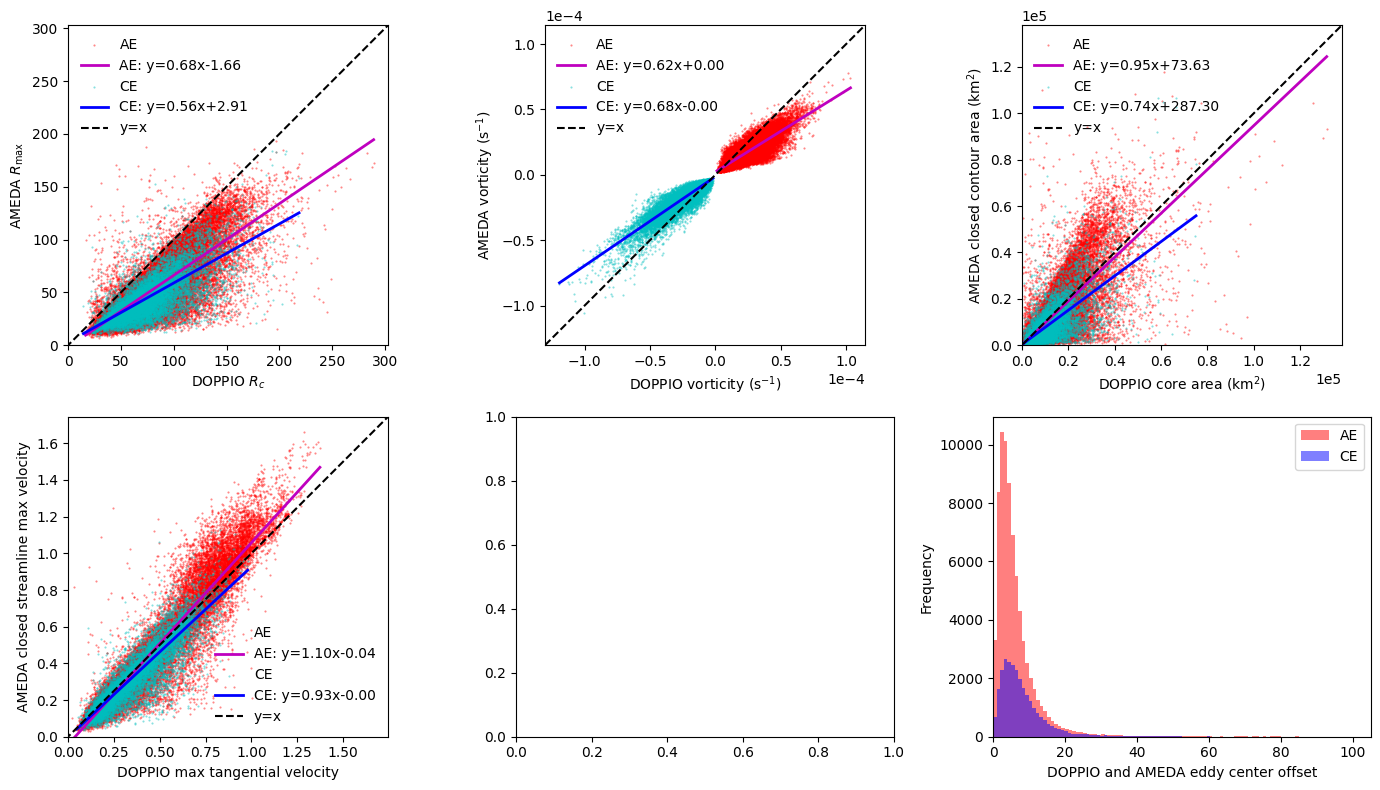

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
compare_phys_geom(df_phys_geom_QC, 'Rc', 'rmax', ax = axs[0,0])
axs[0,0].set_xlabel(r'DOPPIO $R_c$')
axs[0,0].set_ylabel(r'AMEDA $R_\text{max}$')
axs[0,0].set_xlim(0, None); axs[0,0].set_ylim(0, None)

compare_phys_geom(df_phys_geom_QC, 'gw', 'pw', ax = axs[0,1])
axs[0,1].set_xlabel(r'DOPPIO vorticity (s$^{-1}$)')
axs[0,1].set_ylabel(r'AMEDA vorticity (s$^{-1}$)')
axs[0,1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axs[0,1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

df_phys_geom_QC['g_core_area'] = np.pi * df_phys_geom_QC.Rc**2 / 2
compare_phys_geom(df_phys_geom_QC, 'g_core_area', 'area', ax = axs[0,2])
axs[0,2].set_xlabel(r'DOPPIO core area (km$^2$)')
axs[0,2].set_ylabel(r'AMEDA closed contour area (km$^2$)')
axs[0,2].set_xlim(0, None); axs[0,2].set_ylim(0, None)
axs[0,2].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axs[0,2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

df_phys_geom_QC['VT_max'] = df_phys_geom_QC.Omega.abs()*(df_phys_geom_QC.Rc*1e3)*np.exp(-.5)/np.sqrt(2)
compare_phys_geom(df_phys_geom_QC, 'VT_max', 'velmax', ax = axs[1,0], one_to_one=True)
axs[1,0].set_xlabel(r'DOPPIO max tangential velocity')
axs[1,0].set_ylabel(r'AMEDA closed streamline max velocity')
axs[1,0].set_xlim(0, None); axs[1,0].set_ylim(0, None)

df_phys_geom_QC['xcyc_diff'] = np.hypot(
    df_phys_geom_QC.gxc - df_phys_geom_QC.pxc,
    df_phys_geom_QC.gyc - df_phys_geom_QC.pyc
)

for cyc, color in zip(['AE', 'CE'], ['r', 'b']):
    axs[1,2].hist(
        df_phys_geom_QC.loc[df_phys_geom_QC.Cyc.eq(cyc), 'xcyc_diff'],
        bins=100,
        alpha=0.5,
        label=cyc,
        color=color
    )

axs[1,2].legend()
axs[1,2].set_xlim(0, None); axs[1,2].set_ylim(0, None)
axs[1,2].set_xlabel('DOPPIO and AMEDA eddy center offset')
axs[1,2].set_ylabel('Frequency')

plt.tight_layout()


1. DOPPIO Rc > AMEDA rmax
2. DOPPIO vort > AMEDA vort

In [12]:
df_phys_geom_QC.columns


Index(['Eddy', 'Day', 'Cyc', 'plon', 'plat', 'pxc', 'pyc', 'pw', 'ke',
       'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'area', 'deta',
       'gxc', 'gyc', 'gw', 'Omega', 'Q', 'Rc', 'psi0', 'R', 'glon', 'glat',
       'AR', 'g_core_area', 'VT_max', 'xcyc_diff'],
      dtype='object')

In [18]:
def plot_geom_vs_phys_examples(
    df,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid,
    nrows=6,
    ncols=6,
    figsize=(12, 12),
    seed=None
):

    if seed is not None:
        np.random.seed(seed)

    valid_Q = df['Q'].apply(
        lambda Q: isinstance(Q, np.ndarray)
        and Q.shape == (2, 2)
        and np.isfinite(Q).all()
    )

    valid_Rc = np.isfinite(df['Rc']) & (df['Rc'] > 0)

    valid = valid_Q & valid_Rc

    n = nrows * ncols

    idxs = np.random.choice(df.index[valid], n, replace=False)

    points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
    values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, idxs):

        data = df.loc[idx]

        color = 'r' if data.Cyc == 'AE' else 'c'

        ax.scatter(data.gxc, data.gyc, marker='x', c='k', s=15)
        ax.scatter(data.pxc, data.pyc, marker='^', c='k', s=15)

        pad = 2.5 * data.rmax

        xg = np.linspace(data.gxc - pad, data.gxc + pad, 200)
        yg = np.linspace(data.gyc - pad, data.gyc + pad, 200)

        Xg, Yg = np.meshgrid(xg, yg)

        dx = Xg - data.gxc
        dy = Yg - data.gyc

        rho2 = (
            data.Q[0,0] * dx**2
            + 2 * data.Q[1,0] * dx * dy
            + data.Q[1,1] * dy**2
        )

        ax.contour(
            Xg,
            Yg,
            rho2,
            levels=[data.Rc**2 / 2],
            colors=color,
            linestyles='-'
        )

        xy = griddata(
            points,
            values,
            data.shapes1.vertices,
            method='linear'
        )

        ax.plot(xy[:, 0], xy[:, 1], color=color, ls='--')

        ax.set_aspect('equal')

        ax.set_xlim(data.gxc - pad, data.gxc + pad)
        ax.set_ylim(data.gyc - pad, data.gyc + pad)

        ax.set_title(
            f'E{data.Eddy} D{data.Day}',
            fontsize=8
        )

    return fig, axes
    

(<Figure size 1200x1200 with 36 Axes>,
 array([<Axes: title={'center': 'E2492 D8049'}>,
        <Axes: title={'center': 'E3319 D10116'}>,
        <Axes: title={'center': 'E2201 D7242'}>,
        <Axes: title={'center': 'E1805 D6258'}>,
        <Axes: title={'center': 'E3140 D9615'}>,
        <Axes: title={'center': 'E1974 D6705'}>,
        <Axes: title={'center': 'E550 D2969'}>,
        <Axes: title={'center': 'E1890 D6476'}>,
        <Axes: title={'center': 'E1573 D5696'}>,
        <Axes: title={'center': 'E610 D3153'}>,
        <Axes: title={'center': 'E631 D3237'}>,
        <Axes: title={'center': 'E2923 D9219'}>,
        <Axes: title={'center': 'E3051 D9410'}>,
        <Axes: title={'center': 'E1369 D5197'}>,
        <Axes: title={'center': 'E245 D2073'}>,
        <Axes: title={'center': 'E978 D4181'}>,
        <Axes: title={'center': 'E3002 D9305'}>,
        <Axes: title={'center': 'E388 D2784'}>,
        <Axes: title={'center': 'E1655 D5897'}>,
        <Axes: title={'center': 'E2

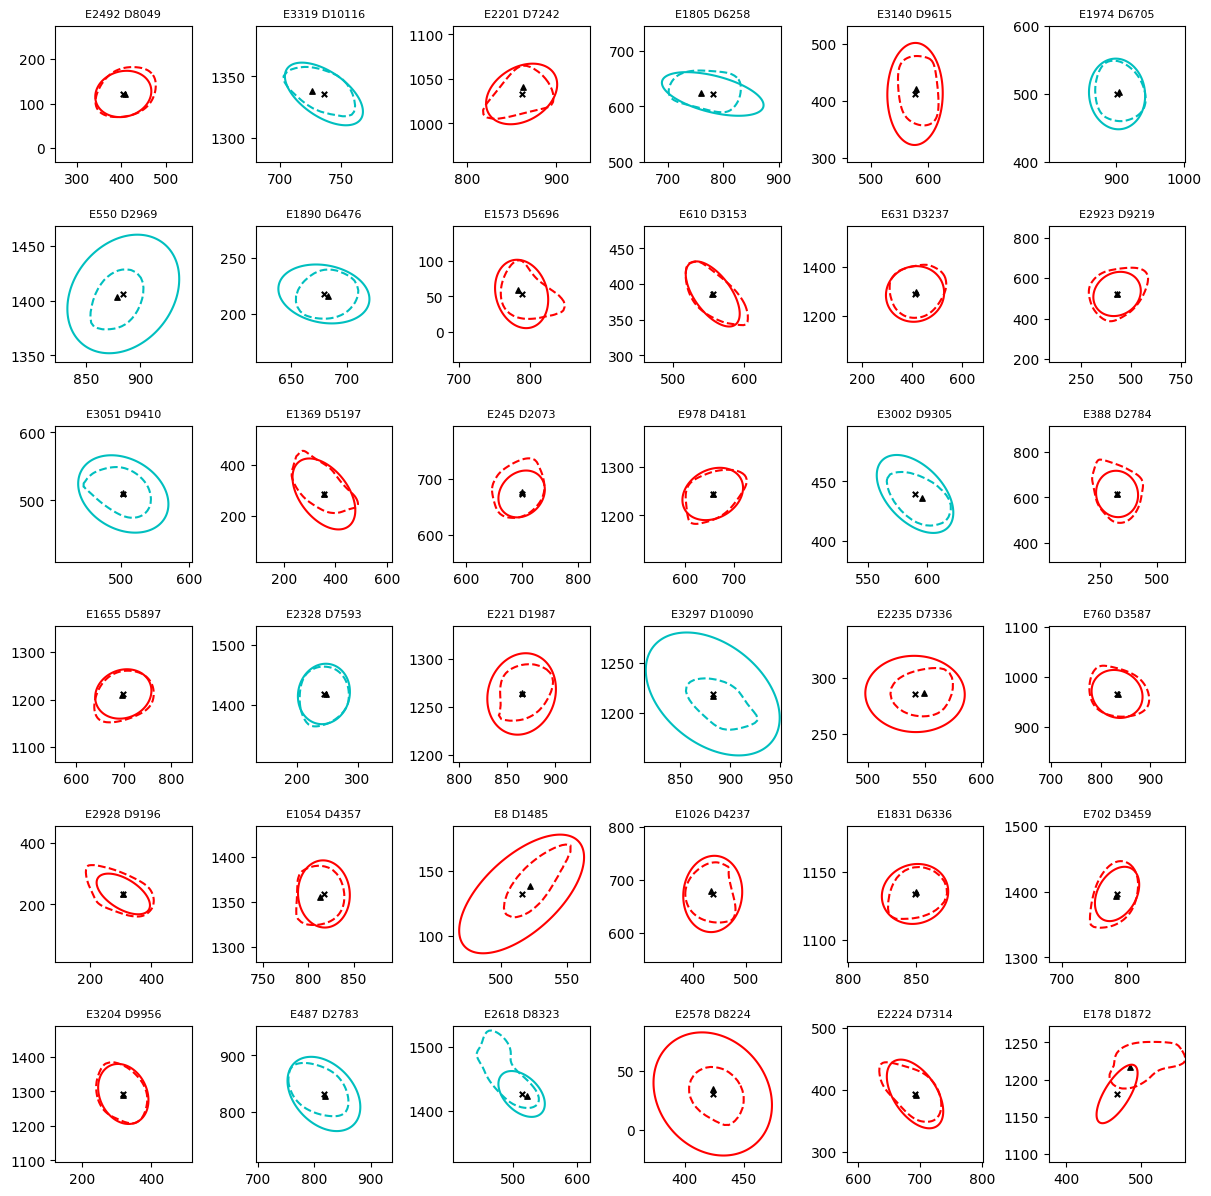

In [19]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


(array([3.9710e+03, 1.0030e+04, 1.2763e+04, 1.2808e+04, 1.1273e+04,
        9.3450e+03, 7.8100e+03, 6.2760e+03, 4.9630e+03, 3.9510e+03,
        3.2050e+03, 2.6160e+03, 2.0890e+03, 1.7440e+03, 1.4420e+03,
        1.1300e+03, 8.9800e+02, 7.1800e+02, 6.3900e+02, 5.3300e+02,
        4.2600e+02, 3.5200e+02, 2.9200e+02, 2.6200e+02, 2.4300e+02,
        1.9700e+02, 1.7900e+02, 1.5700e+02, 1.5000e+02, 1.1600e+02,
        1.1200e+02, 9.8000e+01, 9.9000e+01, 8.1000e+01, 7.8000e+01,
        7.2000e+01, 5.4000e+01, 5.9000e+01, 6.2000e+01, 4.6000e+01,
        4.5000e+01, 5.0000e+01, 4.1000e+01, 3.8000e+01, 4.2000e+01,
        3.8000e+01, 4.6000e+01, 2.9000e+01, 2.6000e+01, 2.7000e+01,
        2.3000e+01, 2.6000e+01, 2.1000e+01, 1.9000e+01, 2.0000e+01,
        2.5000e+01, 2.0000e+01, 1.3000e+01, 1.8000e+01, 2.2000e+01,
        1.5000e+01, 1.4000e+01, 9.0000e+00, 1.7000e+01, 1.1000e+01,
        1.0000e+01, 9.0000e+00, 1.9000e+01, 1.1000e+01, 1.3000e+01,
        1.2000e+01, 9.0000e+00, 1.2000e+01, 1.20

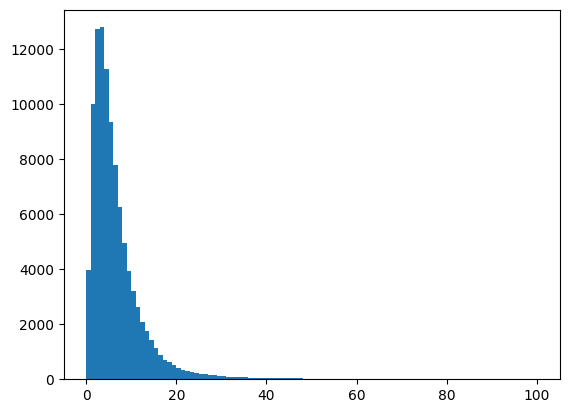

In [15]:
plt.hist(np.hypot(df_phys_geom_QC.pxc - df_phys_geom_QC.gxc, df_phys_geom_QC.pyc - df_phys_geom_QC.gyc), bins=100)


In [22]:
# def day_plot(day, df_ameda, out_core_flag=False, center_flag=False):

#     fnumber = 1461 + ((day - 1462) // 30) * 30
#     fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'

#     with nc.Dataset(fname) as ds:
#         ocean_time = ds['ocean_time'][:] / 86400
#         t = np.where(ocean_time == day)[0][0]
#         ut = ds['u_eastward'][t, -1].T
#         vt = ds['v_northward'][t, -1].T

#     df_day = df_ameda.loc[df_ameda.Day.eq(day)].copy()
#     cs = np.hypot(ut, vt)

#     fig, ax = plt.subplots(figsize=(8, 10))

#     im = ax.pcolor(
#         X_grid, Y_grid, cs,
#         shading='nearest',
#         vmin=0, vmax=2.5,
#         cmap='Blues_r'
#     )
#     fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

#     clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')

#     ax.scatter(
#         df_day.gxc, df_day.gyc,
#         c=clrs,
#         marker='x',
#         s=60,
#         linewidths=1.5,
#         zorder=10,
#         label='Geometric center'
#     )

#     ax.scatter(
#         df_day.pxc, df_day.pyc,
#         c=clrs,
#         marker='^',
#         s=60,
#         edgecolors='k',
#         linewidths=0.6,
#         zorder=10,
#         label='Physical center'
#     )

#     if center_flag:

#         if 'Q' not in df_day.columns:
#             df_day['Q'] = list(np.stack([
#                 np.stack([df_day.q11.values, df_day.q12.values], axis=1),
#                 np.stack([df_day.q12.values, df_day.q22.values], axis=1)
#             ], axis=1))

#         points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
#         values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

#         for _, row in df_day.iterrows():

#             col = 'r' if row.Cyc == 'AE' else 'c'
#             if ~np.isnan(row.Q).all():
#                 dx = X_grid - row.gxc
#                 dy = Y_grid - row.gyc
           
#                 rho2 = (
#                     row.Q[0, 0] * dx**2
#                     + 2 * row.Q[1, 0] * dx * dy
#                     + row.Q[1, 1] * dy**2
#                 )
    
#                 ax.contour(
#                     X_grid, Y_grid, rho2,
#                     levels=[row.Rc**2 / 2],
#                     colors=col,
#                     linestyles='--',
#                     linewidths=1.2
#                 )
    
#                 if out_core_flag:
#                     ax.contour(
#                         X_grid, Y_grid, rho2,
#                         levels=[(1.75 * row.R)**2],
#                         colors=col,
#                         linestyles='--',
#                         linewidths=1.2
#                     )

#             ax.annotate(
#                 str(row.Eddy),
#                 (row.gxc, row.gyc),
#                 textcoords='offset points',
#                 xytext=(3, 3),
#                 fontsize=12,
#                 color='w',
#                 weight='bold',
#                 path_effects=[pe.withStroke(linewidth=2, foreground='k')],
#                 zorder=11
#             )

#             if pd.notna(row.shapes1):
#                 verts = row.shapes1.vertices

#                 xy = griddata(
#                     points,
#                     values,
#                     (verts[:, 0], verts[:, 1]),
#                     method='linear'
#                 )

#                 good = np.isfinite(xy).all(axis=1)

#                 ax.plot(
#                     xy[good, 0],
#                     xy[good, 1],
#                     color=col,
#                     linewidth=1.3,
#                     zorder=9
#                 )

#     c1 = ax.contour(
#         X_grid, Y_grid, lat_rho,
#         levels=[-40, -35, -30, -25],
#         colors='k',
#         linewidths=0.5
#     )
#     ax.clabel(c1, fmt=lambda v: f'{abs(v):.0f}°S', inline=True, colors='k')

#     c2 = ax.contour(
#         X_grid, Y_grid, lon_rho,
#         levels=[150, 155, 160],
#         colors='k',
#         linewidths=0.5
#     )
#     ax.clabel(c2, fmt=lambda v: f'{v:.0f}°E', inline=True, colors='k')

#     date = pd.Timestamp('1990-01-01') + pd.Timedelta(days=day)

#     ax.set_title(f'Day {day} | {date:%Y-%m-%d}')
#     ax.set_aspect('equal', adjustable='datalim')
#     ax.set_xlabel('x (km)')
#     ax.set_ylabel('y (km)')
#     ax.set_xlim(x_grid.min(), x_grid.max())
#     ax.set_ylim(y_grid.min(), y_grid.max())

#     return fig, ax

def day_plot(day, df_eddies, df_ameda, out_core_flag=False, center_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()
    df_day_ameda = df_ameda.loc[df_ameda.Day.eq(day)].copy()
    
    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=20, zorder=10)

    clrs_ameda = np.where(df_day_ameda.Cyc.eq('CE'), 'c', 'r')
    # ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='^', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=30, zorder=10)
    ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, linewidths=0.8, s=80, zorder=9)

    for e, xc, yc in zip(df_day_ameda.Eddy, df_day_ameda.xc, df_day_ameda.yc):
        ax.annotate(
            str(e), (xc, yc),
            textcoords='offset points', xytext=(3, -8),
            fontsize=10, color='orange', weight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
            zorder=11
        )

    if center_flag: 
    
        if 'Q' not in df_day.columns:
            df_day['Q'] = list(
                np.stack([
                    np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                    np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                ], axis=1)
            )
    
        for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):
    
            # ----- Where I plot the eddy's maximum tangenital velocity contour -----
            dx_ell, dy_ell = X_grid - xc, Y_grid - yc
            rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c', linestyles='-')
            if out_core_flag:
                ax.contour(X_grid, Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='-', colors='r' if cyc=='AE' else 'c')
            # -----------------------------------------------------------------------
    
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=10, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

        points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
        values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
        
        for _, data in df_day_ameda.iterrows():
        
            xy = griddata(
                points,
                values,
                (data.shapes1.vertices[:, 0],
                 data.shapes1.vertices[:, 1]),
                method='linear'
            )
        
            ax.plot(
                xy[:, 0],
                xy[:, 1],
                color='r' if data.Cyc == 'AE' else 'c',
                ls='--'
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    

61.030621428358955
39.32437634408653
194.63954875583457
73.74033370879789
69.96435806034685
133.7301097675024
53.378781432152266
59.09948299830301
80.77553069279814
88.13680807781114
43.78817154783468
57.44315556128574
34.52884741187311


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


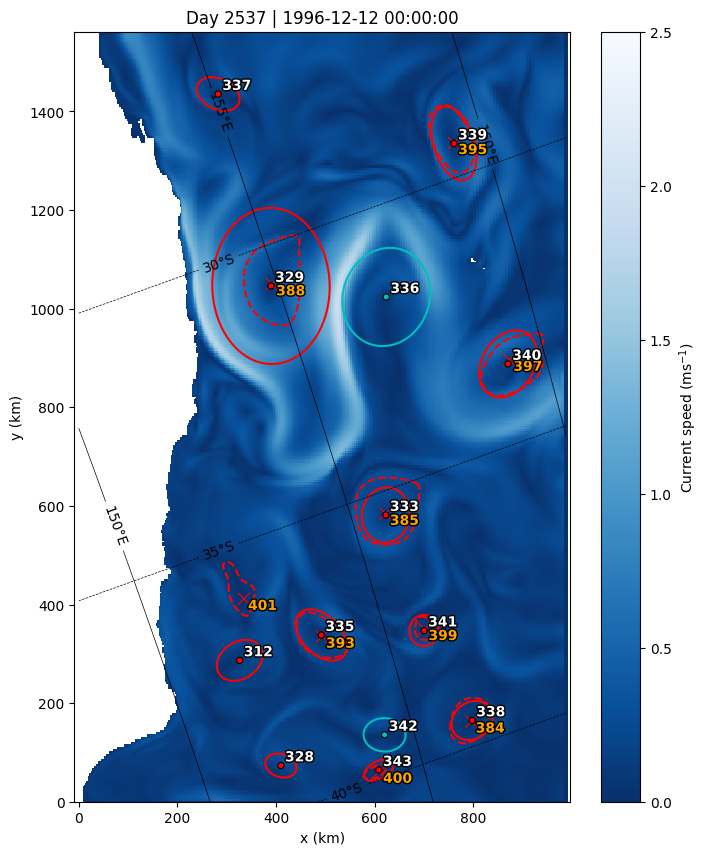

In [23]:
day_plot(2537, df_eddies, df_ameda, center_flag=True, out_core_flag=False)
         